### FED COMPARISON

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import wilcoxon, mannwhitneyu


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

os.makedirs('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/FFvSS', exist_ok=True)

df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['condition'] = 'starved-starved'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['condition'] = 'fed-fed'

df = pd.concat([df1, df2], ignore_index=True)



df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df = df.sort_values(['condition', 'file', 'track_id', 'rel_frame'])


metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['condition', 'file', 'track_id', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

# Average larvae within each file before stats, so each recording contributes once.
first_interaction_file = (
    first_interaction
    .groupby(['condition', 'file', 'interaction_group', 'rel_frame'])[metrics]
    .mean()
    .reset_index()
)


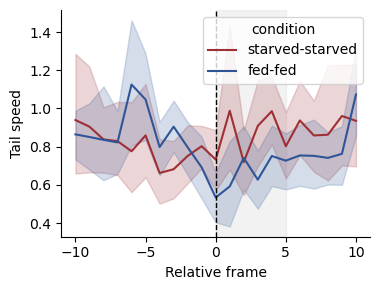

In [2]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='condition',
    hue_order=['starved-starved', 'fed-fed'],
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    errorbar=('ci', 95)
)

plt.axvspan(0, 5, color='0.9', alpha=0.5, zorder=0)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('Tail speed')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/FFvSS/speed.pdf', format='pdf')
plt.show()


In [3]:
# Frames 1-5: average tail speed per file, then independent starved-starved vs fed-fed test
speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_5)
print(speed_1_5.mean())

stat, p = mannwhitneyu(speed_1_5['starved-starved'].dropna(), speed_1_5['fed-fed'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-5, starved-starved vs fed-fed: U={stat:.3g}, p={p:.3g}")


condition,fed-fed,starved-starved
file,,
2026-04-28_12-28-46_td18.tracks.feather,NaN,0.608308
2026-04-28_12-29-05_td19.tracks.feather,NaN,1.216929
2026-04-28_15-17-04_td10.tracks.feather,1.064252,NaN
2026-04-28_15-18-47_td11.tracks.feather,0.612085,NaN
2026-04-28_15-26-11_td8.tracks.feather,NaN,0.467633
2026-05-11_11-28-35_td13.tracks.feather,NaN,0.858577
2026-05-12_14-51-49_td19.tracks.feather,0.455618,NaN
2026-05-12_14-55-40_td11.tracks.feather,NaN,0.742950
2026-05-12_14-56-08_td13.tracks.feather,NaN,0.710768


condition
fed-fed            0.687657
starved-starved    0.880699
dtype: float64
Mann-Whitney U test, frames 1-5, starved-starved vs fed-fed: U=94, p=0.0905


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24271/946407815.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


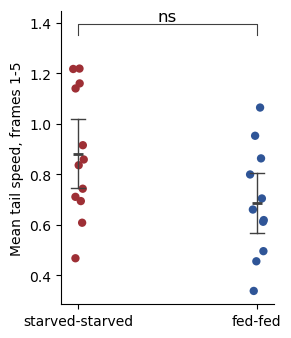

In [4]:
# Plot the values used in the frames 1-5 speed test
speed_1_5_plot = speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved-starved', 'fed-fed'],
    var_name='condition',
    value_name='speed_tail'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['starved-starved', 'fed-fed'],
    hue='condition',
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['starved-starved', 'fed-fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = speed_1_5_plot['speed_tail'].max()
ymin = speed_1_5_plot['speed_tail'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean tail speed, frames 1-5')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/FFvSS/speed_mean.pdf', format='pdf')
plt.show()


In [5]:
# Frames 1-5 after contact compared with frames -5 to -1 before contact, tail speed
pre_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(-5, -1)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

post_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

change_speed_1_5 = post_speed_1_5 - pre_speed_1_5

display(pd.concat({'pre': pre_speed_1_5, 'post': post_speed_1_5, 'post_minus_pre': change_speed_1_5}, axis=1))
print('Mean pre:')
print(pre_speed_1_5.mean())
print('\nMean post:')
print(post_speed_1_5.mean())
print('\nMean post - pre:')
print(change_speed_1_5.mean())

starved_starved_pairs = pd.concat([pre_speed_1_5['starved-starved'], post_speed_1_5['starved-starved']], axis=1, keys=['pre', 'post']).dropna()
stat, p_starved_starved = wilcoxon(starved_starved_pairs['pre'], starved_starved_pairs['post'])
print(f"starved-starved pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved_starved:.3g}")

fed_fed_pairs = pd.concat([pre_speed_1_5['fed-fed'], post_speed_1_5['fed-fed']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_fed = wilcoxon(fed_fed_pairs['pre'], fed_fed_pairs['post'])
print(f"fed-fed pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_fed:.3g}")

stat, change_p = mannwhitneyu(change_speed_1_5['starved-starved'].dropna(), change_speed_1_5['fed-fed'].dropna(), alternative='two-sided')
print(f"Change score, tail speed starved-starved vs fed-fed, frames 1-5: U={stat:.3g}, p={change_p:.3g}")


pre                      post  \
condition                                 fed-fed starved-starved   fed-fed   
file                                                                          
2026-04-28_12-28-46_td18.tracks.feather       NaN        1.069613       NaN   
2026-04-28_12-29-05_td19.tracks.feather       NaN        0.754442       NaN   
2026-04-28_15-17-04_td10.tracks.feather  1.105869             NaN  1.064252   
2026-04-28_15-18-47_td11.tracks.feather  0.874476             NaN  0.612085   
2026-04-28_15-26-11_td8.tracks.feather        NaN        0.414148       NaN   
2026-05-11_11-28-35_td13.tracks.feather       NaN        0.656422       NaN   
2026-05-12_14-51-49_td19.tracks.feather  0.782263             NaN  0.455618   
2026-05-12_14-55-40_td11.tracks.feather       NaN        1.008972       NaN   
2026-05-12_14-56-08_td13.tracks.feather       NaN        0.464180       NaN   
2026-05-18_12-02-50_td17.tracks.feather  0.889437             NaN  0.618715   
2026-05-18_12-06-01_td19.tracks.feather  1.044948             NaN  0.704319   
2026-05-18_12-11-26_td14.tracks.feather       NaN        0.916027       NaN   
2026-05-18_15-15-17_td1.tracks.feather   1.142123             NaN  0.495723   
2026-05-18_15-18-00_td2.tracks.feather   1.071161             NaN  0.862987   
2026-05-18_15-20-40_td5.tracks.feather   0.562789             NaN  0.660478   
2026-05-18_15-29-11_td13.tracks.feather       NaN        0.549698       NaN   
2026-06-05_12-11-35_td17.tracks.feather  0.794429             NaN  0.799302   
2026-06-05_12-13-24_td16.tracks.feather  0.774814             NaN  0.952487   
2026-06-05_12-16-27_td13.tracks.feather       NaN        0.646305       NaN   
2026-06-22_12-08-50_td14.tracks.feather  0.281773             NaN  0.338258   
2026-06-22_12-15-09_td18.tracks.feather       NaN        1.060351       NaN   
2026-06-23_15-58-45_td12.tracks.feather       NaN        1.085551       NaN   
2026-06-23_15-59-36_td14.tracks.feather       NaN        0.390416       NaN   

                                                        post_minus_pre  \
condition                               starved-starved        fed-fed   
file                                                                     
2026-04-28_12-28-46_td18.tracks.feather        0.608308            NaN   
2026-04-28_12-29-05_td19.tracks.feather        1.216929            NaN   
2026-04-28_15-17-04_td10.tracks.feather             NaN      -0.041616   
2026-04-28_15-18-47_td11.tracks.feather             NaN      -0.262391   
2026-04-28_15-26-11_td8.tracks.feather         0.467633            NaN   
2026-05-11_11-28-35_td13.tracks.feather        0.858577            NaN   
2026-05-12_14-51-49_td19.tracks.feather             NaN      -0.326645   
2026-05-12_14-55-40_td11.tracks.feather        0.742950            NaN   
2026-05-12_14-56-08_td13.tracks.feather        0.710768            NaN   
2026-05-18_12-02-50_td17.tracks.feather             NaN      -0.270722   
2026-05-18_12-06-01_td19.tracks.feather             NaN      -0.340629   
2026-05-18_12-11-26_td14.tracks.feather        0.915160            NaN   
2026-05-18_15-15-17_td1.tracks.feather              NaN      -0.646399   
2026-05-18_15-18-00_td2.tracks.feather              NaN      -0.208174   
2026-05-18_15-20-40_td5.tracks.feather              NaN       0.097689   
2026-05-18_15-29-11_td13.tracks.feather        1.159797            NaN   
2026-06-05_12-11-35_td17.tracks.feather             NaN       0.004873   
2026-06-05_12-13-24_td16.tracks.feather             NaN       0.177673   
2026-06-05_12-16-27_td13.tracks.feather        0.693997            NaN   
2026-06-22_12-08-50_td14.tracks.feather             NaN       0.056484   
2026-06-22_12-15-09_td18.tracks.feather        1.218555            NaN   
2026-06-23_15-58-45_td12.tracks.feather        0.835875            NaN   
2026-06-23_15-59-36_td14.tracks.feather        1.139843            NaN   

                                                         
conditio

Mean pre:
condition
fed-fed            0.847644
starved-starved    0.751344
dtype: float64

Mean post:
condition
fed-fed            0.687657
starved-starved    0.880699
dtype: float64

Mean post - pre:
condition
fed-fed           -0.159987
starved-starved    0.129356
dtype: float64
starved-starved pre vs post, tail speed frames 1-5: W=25, p=0.301
fed-fed pre vs post, tail speed frames 1-5: W=13, p=0.083
Change score, tail speed starved-starved vs fed-fed, frames 1-5: U=98, p=0.0525


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24271/4219399069.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


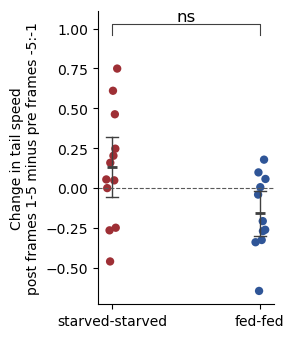

In [6]:
# Plot the values used in the frames 1-5 speed change-score test
change_speed_1_5_plot = change_speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved-starved', 'fed-fed'],
    var_name='condition',
    value_name='speed_change'
)

if change_p < 0.001:
    stars = '***'
elif change_p < 0.01:
    stars = '**'
elif change_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['starved-starved', 'fed-fed'],
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    hue='condition',
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['starved-starved', 'fed-fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

plt.axhline(0, color='0.35', linewidth=0.8, linestyle='--')

ymax = change_speed_1_5_plot['speed_change'].max()
ymin = change_speed_1_5_plot['speed_change'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Change in tail speed\npost frames 1-5 minus pre frames -5:-1')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/FFvSS/speed_baseline_change.pdf', format='pdf')
plt.show()


In [7]:
# Test whether each condition changes from before to after contact, frames 1-5
starved_starved_pairs = pd.concat([pre_speed_1_5['starved-starved'], post_speed_1_5['starved-starved']], axis=1, keys=['pre', 'post']).dropna()
stat, p_starved_starved = wilcoxon(starved_starved_pairs['pre'], starved_starved_pairs['post'])
print(f"starved-starved pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved_starved:.3g}")
print(f"starved-starved mean change: {change_speed_1_5['starved-starved'].mean():.3g}")

fed_fed_pairs = pd.concat([pre_speed_1_5['fed-fed'], post_speed_1_5['fed-fed']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_fed = wilcoxon(fed_fed_pairs['pre'], fed_fed_pairs['post'])
print(f"fed-fed pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_fed:.3g}")
print(f"fed-fed mean change: {change_speed_1_5['fed-fed'].mean():.3g}")


starved-starved pre vs post, tail speed frames 1-5: W=25, p=0.301
starved-starved mean change: 0.129
fed-fed pre vs post, tail speed frames 1-5: W=13, p=0.083
fed-fed mean change: -0.16


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24271/2294050006.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24271/2294050006.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


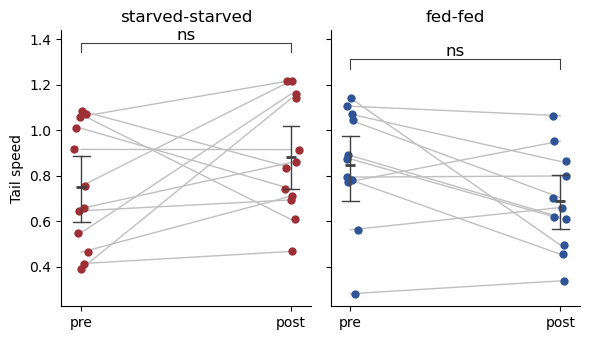

In [8]:
# Plot pre vs post tail speed within each condition, frames 1-5
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

for ax, condition, color, test_p in zip(
    axes,
    ['starved-starved', 'fed-fed'],
    ['#9E2F35', '#2F5597'],
    [p_starved_starved, p_fed_fed]
):
    plot_data = pd.DataFrame({
        'file': pre_speed_1_5.index,
        'pre': pre_speed_1_5[condition],
        'post': post_speed_1_5[condition]
    }).dropna()
    long_plot_data = plot_data.melt(
        id_vars='file',
        value_vars=['pre', 'post'],
        var_name='time',
        value_name='speed_tail'
    )

    if test_p < 0.001:
        stars = '***'
    elif test_p < 0.01:
        stars = '**'
    elif test_p < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    for _, row in plot_data.iterrows():
        ax.plot([0, 1], [row['pre'], row['post']], color='0.75', linewidth=1, zorder=1)

    sns.stripplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        color=color,
        size=6,
        jitter=0.04,
        ax=ax,
        zorder=2
    )

    sns.pointplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        errorbar=('ci', 95),
        color='0.25',
        markers='_',
        linestyles='none',
        capsize=0.08,
        err_kws={'linewidth': 1},
        join=False,
        ax=ax
    )

    ymax = long_plot_data['speed_tail'].max()
    ymin = long_plot_data['speed_tail'].min()
    y_range = ymax - ymin if ymax > ymin else 1
    y = ymax + y_range * 0.15
    h = y_range * 0.05
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
    ax.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

    ax.set_title(condition)
    ax.set_xlabel('')
    ax.set_ylabel('Tail speed' if condition == 'starved-starved' else '')

sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/FFvSS/speed_baseline_change_within_condition.pdf', format='pdf')
plt.show()


In [9]:
# Frames 1-10: average tail speed per file, then independent starved-starved vs fed-fed test
speed_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_10)
print(speed_1_10.mean())

stat, p = mannwhitneyu(speed_1_10['starved-starved'].dropna(), speed_1_10['fed-fed'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-10, starved-starved vs fed-fed: U={stat:.3g}, p={p:.3g}")


condition,fed-fed,starved-starved
file,,
2026-04-28_12-28-46_td18.tracks.feather,NaN,0.802435
2026-04-28_12-29-05_td19.tracks.feather,NaN,1.311448
2026-04-28_15-17-04_td10.tracks.feather,1.081082,NaN
2026-04-28_15-18-47_td11.tracks.feather,0.625894,NaN
2026-04-28_15-26-11_td8.tracks.feather,NaN,0.513350
2026-05-11_11-28-35_td13.tracks.feather,NaN,0.865018
2026-05-12_14-51-49_td19.tracks.feather,0.557356,NaN
2026-05-12_14-55-40_td11.tracks.feather,NaN,0.911110
2026-05-12_14-56-08_td13.tracks.feather,NaN,0.653971


condition
fed-fed            0.752116
starved-starved    0.895778
dtype: float64
Mann-Whitney U test, frames 1-10, starved-starved vs fed-fed: U=90, p=0.148


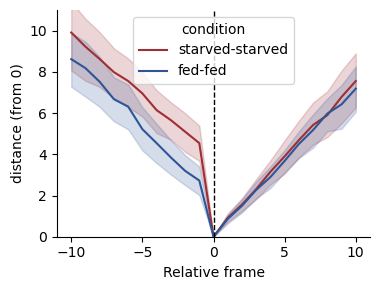

In [10]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='condition',
    hue_order=['starved-starved', 'fed-fed'],
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    errorbar=('ci', 95)
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('distance (from 0)')
sns.despine()
plt.tight_layout()
plt.ylim(0,11)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/FFvSS/distance_from_0.pdf', format='pdf')
plt.show()


In [11]:
# Frames 1-5: average distance_from_0 per file, then independent starved-starved vs fed-fed test
distance_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_5)
print(distance_1_5.mean())

stat, p = mannwhitneyu(distance_1_5['starved-starved'].dropna(), distance_1_5['fed-fed'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-5, starved-starved vs fed-fed: U={stat:.3g}, p={p:.3g}")


condition,fed-fed,starved-starved
file,,
2026-04-28_12-28-46_td18.tracks.feather,NaN,1.571258
2026-04-28_12-29-05_td19.tracks.feather,NaN,2.412381
2026-04-28_15-17-04_td10.tracks.feather,3.173181,NaN
2026-04-28_15-18-47_td11.tracks.feather,1.430154,NaN
2026-04-28_15-26-11_td8.tracks.feather,NaN,0.920392
2026-05-11_11-28-35_td13.tracks.feather,NaN,2.488065
2026-05-12_14-51-49_td19.tracks.feather,2.160087,NaN
2026-05-12_14-55-40_td11.tracks.feather,NaN,1.919983
2026-05-12_14-56-08_td13.tracks.feather,NaN,1.467945


condition
fed-fed            2.241261
starved-starved    2.367184
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-5, starved-starved vs fed-fed: U=72, p=0.735


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24271/942816567.py:35: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


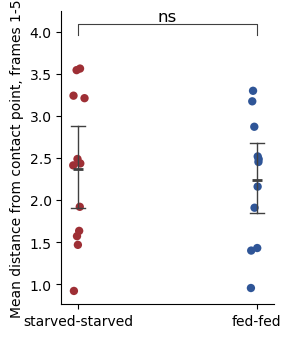

In [12]:
# Plot the values used in the frames 1-5 distance_from_0 test
_, distance_p = mannwhitneyu(distance_1_5['starved-starved'].dropna(), distance_1_5['fed-fed'].dropna(), alternative='two-sided')

distance_1_5_plot = distance_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved-starved', 'fed-fed'],
    var_name='condition',
    value_name='distance_from_0'
)

if distance_p < 0.001:
    stars = '***'
elif distance_p < 0.01:
    stars = '**'
elif distance_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['starved-starved', 'fed-fed'],
    hue='condition',
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['starved-starved', 'fed-fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_5_plot['distance_from_0'].max()
ymin = distance_1_5_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-5')
sns.despine()
plt.tight_layout()
plt.show()


condition,fed-fed,starved-starved
file,,
2026-04-28_12-28-46_td18.tracks.feather,NaN,3.188975
2026-04-28_12-29-05_td19.tracks.feather,NaN,4.223690
2026-04-28_15-17-04_td10.tracks.feather,5.057109,NaN
2026-04-28_15-18-47_td11.tracks.feather,2.805352,NaN
2026-04-28_15-26-11_td8.tracks.feather,NaN,2.363516
2026-05-11_11-28-35_td13.tracks.feather,NaN,4.662820
2026-05-12_14-51-49_td19.tracks.feather,3.443695,NaN
2026-05-12_14-55-40_td11.tracks.feather,NaN,2.906799
2026-05-12_14-56-08_td13.tracks.feather,NaN,2.498192


condition
fed-fed            4.046322
starved-starved    4.217536
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-10, starved-starved vs fed-fed: U=73, p=0.689


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_24271/2433217505.py:47: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


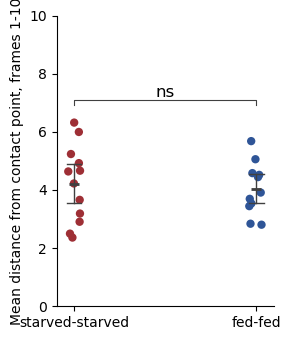

In [13]:
# Frames 1-10: average distance_from_0 per file, then independent starved-starved vs fed-fed test
distance_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_10)
print(distance_1_10.mean())

stat, p = mannwhitneyu(distance_1_10['starved-starved'].dropna(), distance_1_10['fed-fed'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-10, starved-starved vs fed-fed: U={stat:.3g}, p={p:.3g}")

# Plot the values used in the frames 1-10 distance_from_0 test
distance_1_10_plot = distance_1_10.reset_index().melt(
    id_vars='file',
    value_vars=['starved-starved', 'fed-fed'],
    var_name='condition',
    value_name='distance_from_0'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['starved-starved', 'fed-fed'],
    hue='condition',
    palette={'starved-starved': '#9E2F35', 'fed-fed': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['starved-starved', 'fed-fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_10_plot['distance_from_0'].max()
ymin = distance_1_10_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-10')
plt.ylim(0, 10)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/FFvSS/distance_from_0_mean.pdf', format='pdf')
plt.show()
